In [ ]:
import pickle
import gzip
import zlib
import numpy as np
import pandas as pd
import polars as pl
from concurrent.futures import ThreadPoolExecutor
from scipy.signal import hilbert, butter, sosfilt

import pywt
from Functions.Graphs import *
from Functions.Utils import *
fs = 25600

def ReadSamples(path):
    samples = os.listdir(path)
    samples.sort(key=lambda x: int(re.search(r'\d+', x).group()))
    return samples

def load_pkz(file_path):
    with gzip.open(file_path, 'rb') as f:
        return pickle.load(f)
    
def process_single_file(args):
    sample_path, sample_out, fs = args
    df = pl.read_csv(sample_path, n_rows=None, has_header=True) # Ajuste has_header se os CSVs originais tiverem cabeçalho
    df.columns = ['H_vib', 'V_vib']
    df.to_pandas().to_pickle(sample_out)
    return sample_out

def BearingFaultFreq(fr):
    n = 8
    d = 7.92
    D = 34.55
    a = 0
    bpfo = (n/2) * fr * (1 - d*np.cos(a)/D)
    bpfi = (n/2) * fr * (1 + d*np.cos(a)/D)
    bsf = (D/(2*d)) * fr * (1 - (d*np.cos(a)/D)**2)
    ftf = (1/2) * fr * (1 - d*np.cos(a)/D)
    return [bpfo, bpfi, bsf, ftf]


In [ ]:
path = f'C:/Users/Claudio/Desktop/Python/Datasets/XJTU_Bearing/Raw'
out = r'Dataset\XJTU\Raw'

tasks = []
brngs = ReadSamples(path)

for brng in brngs:
    brng_path = os.path.join(path, brng)
    brng_out = os.path.join(out, brng)
    os.makedirs(brng_out, exist_ok=True)

    samples = ReadSamples(brng_path)
    for sample in samples:
        sample_path = os.path.join(brng_path, sample)
        sample_out = os.path.join(brng_out, sample)[:-3] + 'pkz'
        
        # Guarda o par de caminhos na lista de tarefas
        tasks.append((sample_path, sample_out, fs))

print(f"Iniciando o processamento paralelo de {len(tasks)} arquivos...")
with ThreadPoolExecutor() as executor:
    for completed_file in executor.map(process_single_file, tasks):
        print(completed_file)

In [ ]:

class VibrationFeatureExtractor:
    """
    Feature Extractor for 1-second Vibration Signals (25.6 kHz)
    Extracts Kinematic Envelope Features and Wavelet Packet Energy/Entropy Features.
    """
    def __init__(self, fs=25600, fr=30.0, bpfo=107.5, bpfi=162.5, bsf=73.33, ftf=13.49):
        """
        Parameters:
        -----------
        fs   : Sampling frequency (Hz)
        fr   : Shaft rotational frequency (Hz)
        bpfo : Ball Pass Frequency Outer Race (Hz)
        bpfi : Ball Pass Frequency Inner Race (Hz)
        bsf : Ball Spin Frequency (Hz)
        ftf : Fundamental Train Frequency (Hz)
        """
        self.fs = fs
        self.fr = fr
        self.bpfo = bpfo
        self.bpfi = bpfi
        self.bsf = bsf
        self.ftf = ftf

    # -------------------------------------------------------------------------
    # Approach B: Kinematic Frequency Domain (Envelope Analysis)
    # -------------------------------------------------------------------------
    def _bandpass_filter(self, signal, lowcut=2000, highcut=8000, order=4):
        """High/Band-pass filter to isolate structural resonance band."""
        sos = butter(order, [lowcut, highcut], btype='bandpass', fs=self.fs, output='sos')
        return sosfilt(sos, signal)

    def extract_envelope_features(self, signal, band_window=2.0, num_harmonics=3):
        """
        Extracts peak energy around BPFO, BPFI, and BPFI Modulation sidebands.
        """
        # 1. Bandpass filter around structural resonance
        filtered_sig = self._bandpass_filter(signal)
        
        # 2. Compute Hilbert envelope & subtract mean (DC offset)
        analytic_signal = hilbert(filtered_sig)
        envelope = np.abs(analytic_signal)
        envelope_ac = envelope - np.mean(envelope)
        
        # 3. FFT of envelope
        N = len(envelope_ac)
        fft_spectrum = np.abs(np.fft.rfft(envelope_ac)) / N
        fft_freqs = np.fft.rfftfreq(N, d=1/self.fs)
        
        def get_peak_energy(freq_target):
            """Helper to extract peak magnitude around a target frequency."""
            idx = np.where((fft_freqs >= freq_target - band_window) & 
                           (fft_freqs <= freq_target + band_window))[0]
            return np.max(fft_spectrum[idx]) if len(idx) > 0 else 0.0

        # Sum peaks at fundamental and harmonics
        fhr_bpfo = sum([get_peak_energy(m * self.bpfo) for m in range(1, num_harmonics + 1)])
        fhr_bpfi = sum([get_peak_energy(m * self.bpfi) for m in range(1, num_harmonics + 1)])
        fhr_bsf = sum([get_peak_energy(m * self.bsf) for m in range(1, num_harmonics + 1)])
        fhr_ftf = sum([get_peak_energy(m * self.ftf) for m in range(1, num_harmonics + 1)])
        
        # Inner Race Modulation Index (Sidebands at BPFI ± fr)
        ir_sideband_low = get_peak_energy(self.bpfi - self.fr)
        ir_sideband_high = get_peak_energy(self.bpfi + self.fr)
        irmi = ir_sideband_low + ir_sideband_high
        bsmi = get_peak_energy(self.bsf - self.ftf) + get_peak_energy(self.bsf + self.ftf)
        
        # Fault Energy Ratios (Ratio of fault peak to total envelope spectrum energy)
        total_env_energy = np.sum(fft_spectrum**2) + 1e-12
        fer_bpfo = (fhr_bpfo**2) / total_env_energy
        fer_bpfi = (fhr_bpfi**2) / total_env_energy
        fer_bsf  = (fhr_bsf**2)  / total_env_energy
        fer_ftf  = (fhr_ftf**2)  / total_env_energy

        return {
            "FHR_BPFO": fhr_bpfo,
            "FHR_BPFI": fhr_bpfi,
            "FHR_BSF":  fhr_bsf,
            "FHR_FTF":  fhr_ftf,
            "FER_BPFO": fer_bpfo,
            "FER_BPFI": fer_bpfi,
            "FER_BSF":  fer_bsf,
            "FER_FTF":  fer_ftf,
            "IRMI": irmi,
            "BSMI": bsmi
        }

    # -------------------------------------------------------------------------
    # Approach C: Time-Frequency Domain (Wavelet Packet Decomposition)
    # -------------------------------------------------------------------------
    def extract_wpd_features(self, signal, wavelet='db4', level=3):
        """
        Extracts sub-band energy vector and energy entropy from a 3-level WPD.
        """
        wp = pywt.WaveletPacket(data=signal, wavelet=wavelet, mode='symmetric', maxlevel=level)
        
        # Corrected 'order' argument to 'freq'
        nodes = [node.path for node in wp.get_level(level, order='freq')]
        
        # Calculate energy for each terminal sub-band node
        node_energies = np.array([np.sum(wp[node].data**2) for node in nodes])
        total_energy = np.sum(node_energies) + 1e-12
        
        # Energy Ratios (Normalized energy distribution vector)
        energy_ratios = node_energies / total_energy
        
        # Wavelet Packet Energy Entropy
        wpd_entropy = -np.sum(energy_ratios * np.log(energy_ratios + 1e-12))
        
        wpd_dict = {f"WPD_E_Node{i}": energy_ratios[i] for i in range(len(nodes))}
        wpd_dict["WPD_Entropy"] = wpd_entropy
        
        return wpd_dict

    # -------------------------------------------------------------------------
    # Master Processing Method
    # -------------------------------------------------------------------------
    def process_sample(self, signal,level=3):
        """Extracts all envelope and WPD features for a single sample vector."""
        env_feats = self.extract_envelope_features(signal)
        wpd_feats = self.extract_wpd_features(signal,level=level)
        return {**env_feats, **wpd_feats}

    def process_run_to_failure_dataset(self, dataset):
        """
        Processes an entire array of run-to-failure samples.
        
        Parameters:
        -----------
        dataset : numpy array of shape (K_samples, N_points)
        
        Returns:
        --------
        pd.DataFrame containing feature matrix across time step k = 1...K
        """
        features_list = []
        for k in range(dataset.shape[0]):
            sample_features = self.process_sample(dataset[k, :])
            features_list.append(sample_features)
            
        df_features = pd.DataFrame(features_list)
        df_features.index.name = "sample_k"
        return df_features

In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import hilbert, butter, sosfilt
import pywt
import math

class VibrationFeatureExtractor:
    """
    Feature Extractor for 1-second Vibration Signals (25.6 kHz)
    Extracts Kinematic Envelope Features, Wavelet Packet Energy/Entropy Features,
    and Advanced Non-Linear Complexity / Cage Modulation Features.
    """
    def __init__(self, fs=25600, fr=30.0, bpfo=107.5, bpfi=162.5, bsf=73.33, ftf=13.49):
        """
        Parameters:
        -----------
        fs   : Sampling frequency (Hz)
        fr   : Shaft rotational frequency (Hz)
        bpfo : Ball Pass Frequency Outer Race (Hz)
        bpfi : Ball Pass Frequency Inner Race (Hz)
        bsf  : Ball Spin Frequency (Hz)
        ftf  : Fundamental Train Frequency / Cage (Hz)
        """
        self.fs = fs
        self.fr = fr
        self.bpfo = bpfo
        self.bpfi = bpfi
        self.bsf = bsf
        self.ftf = ftf

    # -------------------------------------------------------------------------
    # Approach B: Kinematic Frequency Domain (Envelope & Sideband Analysis)
    # -------------------------------------------------------------------------
    def _bandpass_filter(self, signal, lowcut=2000, highcut=9000, order=4):
        """High/Band-pass filter to isolate structural resonance band."""
        sos = butter(order, [lowcut, highcut], btype='bandpass', fs=self.fs, output='sos')
        return sosfilt(sos, signal)

    def extract_envelope_features(self, signal, band_window=2.0, num_harmonics=3):
        """
        Extracts peak energy, modulation indices, and cage-induced sideband ratios.
        """
        # 1. Bandpass filter around structural resonance
        filtered_sig = self._bandpass_filter(signal)
        
        # 2. Compute Hilbert envelope & subtract mean (DC offset)
        analytic_signal = hilbert(filtered_sig)
        envelope = np.abs(analytic_signal)
        envelope_ac = envelope - np.mean(envelope)
        
        # 3. FFT of envelope
        N = len(envelope_ac)
        fft_spectrum = np.abs(np.fft.rfft(envelope_ac)) / N
        fft_freqs = np.fft.rfftfreq(N, d=1/self.fs)
        
        def get_peak_energy(freq_target):
            """Helper to extract peak magnitude around a target frequency."""
            idx = np.where((fft_freqs >= freq_target - band_window) & 
                           (fft_freqs <= freq_target + band_window))[0]
            return np.max(fft_spectrum[idx]) if len(idx) > 0 else 0.0

        # Sum peaks at fundamental and harmonics
        fhr_bpfo = sum([get_peak_energy(m * self.bpfo) for m in range(1, num_harmonics + 1)])
        fhr_bpfi = sum([get_peak_energy(m * self.bpfi) for m in range(1, num_harmonics + 1)])
        fhr_bsf  = sum([get_peak_energy(m * self.bsf)  for m in range(1, num_harmonics + 1)])
        fhr_ftf  = sum([get_peak_energy(m * self.ftf)  for m in range(1, num_harmonics + 1)])
        
        # Inner Race & Ball Spin Modulation Indices
        ir_sideband_low = get_peak_energy(self.bpfi - self.fr)
        ir_sideband_high = get_peak_energy(self.bpfi + self.fr)
        irmi = ir_sideband_low + ir_sideband_high
        bsmi = get_peak_energy(self.bsf - self.ftf) + get_peak_energy(self.bsf + self.ftf)
        
        # NEW: Cage-Induced Sideband Energy Ratio around BPFO and BPFI (Modulation Ratio)
        # Evaluates sidebands at BPFO ± m*FTF and BPFI ± m*FTF
        bpfo_ftf_sidebands = sum([get_peak_energy(self.bpfo + m * self.ftf) + 
                                  get_peak_energy(self.bpfo - m * self.ftf) for m in [1, 2]])
        bpfo_carrier = get_peak_energy(self.bpfo) + 1e-12
        ftf_sb_ratio_bpfo = bpfo_ftf_sidebands / (bpfo_ftf_sidebands + bpfo_carrier)

        bpfi_ftf_sidebands = sum([get_peak_energy(self.bpfi + m * self.ftf) + 
                                  get_peak_energy(self.bpfi - m * self.ftf) for m in [1, 2]])
        bpfi_carrier = get_peak_energy(self.bpfi) + 1e-12
        ftf_sb_ratio_bpfi = bpfi_ftf_sidebands / (bpfi_ftf_sidebands + bpfi_carrier)

        # Fault Energy Ratios
        total_env_energy = np.sum(fft_spectrum**2) + 1e-12
        fer_bpfo = (fhr_bpfo**2) / total_env_energy
        fer_bpfi = (fhr_bpfi**2) / total_env_energy
        fer_bsf  = (fhr_bsf**2)  / total_env_energy
        fer_ftf  = (fhr_ftf**2)  / total_env_energy

        return {
            "FHR_BPFO": fhr_bpfo,
            "FHR_BPFI": fhr_bpfi,
            "FHR_BSF":  fhr_bsf,
            "FHR_FTF":  fhr_ftf,
            #"FER_BPFO": fer_bpfo,
            #"FER_BPFI": fer_bpfi,
            #"FER_BSF":  fer_bsf,
            #"FER_FTF":  fer_ftf,
            "IRMI": irmi,
            "BSMI": bsmi,
            #"FTF_SB_Ratio_BPFO": ftf_sb_ratio_bpfo,
            #"FTF_SB_Ratio_BPFI": ftf_sb_ratio_bpfi
        }

    # -------------------------------------------------------------------------
    # Approach C: Time-Frequency Domain (Wavelet Packet Decomposition)
    # -------------------------------------------------------------------------
    def extract_wpd_features(self, signal, wavelet='db4', level=3):
        """
        Extracts sub-band energy vector and energy entropy from a 3-level WPD.
        """
        wp = pywt.WaveletPacket(data=signal, wavelet=wavelet, mode='symmetric', maxlevel=level)
        nodes = [node.path for node in wp.get_level(level, order='freq')]
        
        node_energies = np.array([np.sum(wp[node].data**2) for node in nodes])
        total_energy = np.sum(node_energies) + 1e-12
        
        energy_ratios = node_energies / total_energy
        wpd_entropy = -np.sum(energy_ratios * np.log(energy_ratios + 1e-12))
        
        wpd_dict = {f"WPD_E_Node{i}": energy_ratios[i] for i in range(len(nodes))}
        wpd_dict["WPD_Entropy"] = wpd_entropy
        
        return wpd_dict

    # -------------------------------------------------------------------------
    # Master Processing Method
    # -------------------------------------------------------------------------
    def process_sample(self, signal,db='db4',lv=4):
        """Extracts all envelope, WPD, and non-linear features for a single sample."""
        env_feats = self.extract_envelope_features(signal)
        wpd_feats = self.extract_wpd_features(signal,wavelet=db,level=lv)
        #comp_feats = self.extract_complexity_features(signal)
        return {**env_feats, **wpd_feats,
                }

    def process_run_to_failure_dataset(self, dataset):
        """
        Processes an entire array of run-to-failure samples.
        
        Parameters:
        -----------
        dataset : numpy array of shape (K_samples, N_points)
        
        Returns:
        --------
        pd.DataFrame containing feature matrix across time step k = 1...K
        """
        features_list = []
        for k in range(dataset.shape[0]):
            sample_features = self.process_sample(dataset[k, :])
            features_list.append(sample_features)
            
        df_features = pd.DataFrame(features_list)
        df_features.index.name = "sample_k"
        return df_features

In [ ]:
FS = 25600
FR = 37.50
FR = 35
BPFO, BPFI, BSF, FTF = BearingFaultFreq(FR)
extractor = VibrationFeatureExtractor(fs=FS, fr=FR, bpfo=BPFO, bpfi=BPFI)

dsi_frames = []
paths = [r'Dataset\XJTU\Raw\B2_1',r'Dataset\XJTU\Raw\B2_2',r'Dataset\XJTU\Raw\B2_3',r'Dataset\XJTU\Raw\B2_5']
paths = [r'Dataset\XJTU\Raw\B1_1',r'Dataset\XJTU\Raw\B1_2',r'Dataset\XJTU\Raw\B1_3',r'Dataset\XJTU\Raw\B1_4'][:]
for path in paths:
    print(path)
    samples = ReadSamples(path)
    dsi = []
    for sample in samples:
        sample_path = os.path.join(path, sample)
        df = pd.read_pickle(sample_path)
        sig = df['V_vib'].values
        feats = extractor.process_sample(sig)
        dsi.append(np.array(list(feats.values())))
    dsi = pd.DataFrame(dsi)
    dsi.columns = feats.keys()
    dsi_frames.append(dsi)

In [ ]:

frames1 = [dsi_frames[i].iloc[:,0:-1] for i in range(len(dsi_frames))]

PlotFramesPLY(frames1, names=None, cols_qtd=4, w=1500, h=250)

In [ ]:
from numba import njit
from numba import prange
@njit(fastmath=True)
def pearson_correlation(xk, x1):
    """
    Calcula a correlação de Pearson entre dois vetores xk e x1 
    usando Numba para alta performance.
    """
    n = len(xk)
    
    # Verifica se os tamanhos são compatíveis
    if n != len(x1):
        raise ValueError("Os arrays devem ter o mesmo tamanho.")

    # 1. Cálculo das médias (bar_xk e bar_x1 na fórmula)
    mean_k = 0.0
    mean_1 = 0.0
    for i in range(n):
        mean_k += xk[i]
        mean_1 += x1[i]
    mean_k /= n
    mean_1 /= n

    # 2. Cálculo do Numerador e Denominador
    numerator = 0.0
    sum_sq_diff_k = 0.0
    sum_sq_diff_1 = 0.0

    for i in range(n):
        diff_k = xk[i] - mean_k
        diff_1 = x1[i] - mean_1
        
        # Somatório do produto das diferenças (Numerador)
        numerator += diff_k * diff_1
        
        # Somatório dos quadrados das diferenças (partes do Denominador)
        sum_sq_diff_k += diff_k ** 2
        sum_sq_diff_1 += diff_1 ** 2

    # O denominador é a raiz do produto das somas dos quadrados
    # Fórmula: sqrt( sum((xk-mean_k)^2) * sum((x1-mean_1)^2) )
    denominator = np.sqrt(sum_sq_diff_k * sum_sq_diff_1)

    if denominator == 0:
        return 0.0  # Evita divisão por zero se a variância for nula

    return numerator / denominator

In [ ]:
def CalculateSTFT(df,fs=25600,horizontal=True,env=False,nperseg=256,noverlap=None):
    if horizontal:
        x = df.iloc[:,0].values
    else:
        x = df.iloc[:,1].values
    if env:
        x = hilbert(x)
        x = np.abs(x)
    else:
        None
    f, t, Z = stft(x, fs=fs, nperseg=nperseg,noverlap=noverlap)
    Z = np.abs(Z)
    col_names = [f'{val/1000:.2f} kHz' for val in f]
    data_dict = {'time (s)': t}
    Z_data = Z.T if Z.shape[0] == len(f) else Z
    for i, name in enumerate(col_names):
        data_dict[name] = Z_data[:, i]
    df2 = pd.DataFrame(data_dict)
    return df2

In [156]:
path = r'Dataset\XJTU\Raw\B1_1'
samples = ReadSamples(path)
rs = []
for i,sample in enumerate(samples):
    c = np.array([])
    sample_path = os.path.join(path,sample)
    df = pd.read_pickle(sample_path)
    tab = CalculateSTFT(df,fs=25600,horizontal=True,env=False,nperseg=64,noverlap=0).iloc[:,1:]
    Z = tab.values.T
    if i==0:
        Zi = Z
        for j  in range(Z.shape[0]):
            c = np.append(c,pearson_correlation(Z[j], Zi[j]))
        rs.append(c)
    else:
        for j  in range(Z.shape[0]):
            c = np.append(c,pearson_correlation(Z[j], Zi[j]))
        rs.append(c)

In [104]:
path = r'Dataset\XJTU\Raw\B1_1'
samples = ReadSamples(path)
level = 4
rs = [[] for i in range(4+1)]
for i,sample in enumerate(samples):
    sample_path = os.path.join(path,sample)
    df = pd.read_pickle(sample_path)
    x = df['H_vib'].values
    y = df['V_vib'].values
    sig = np.abs(x )
    Zks = pywt.wavedec(sig, wavelet='db4', level=level)
    if i==0:
        Zis = Zks
        for j,_  in enumerate(Zis):
            rs[j].append(pearson_correlation(Zks[j], Zis[j]))
    else:
        for j,_  in enumerate(Zis):
            rs[j].append(pearson_correlation(Zks[j], Zis[j]))

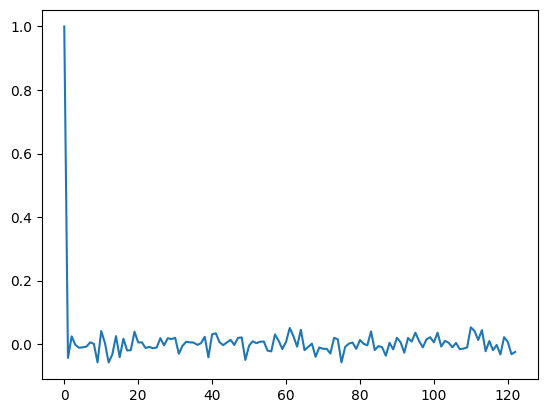

In [105]:
plt.plot(rs[1])

In [ ]:
path = r'Dataset\XJTU\Raw\B1_1\123.pkz'
df = pd.read_pickle(path)
x = df['H_vib'].values
y = df['V_vib'].values
s = x + 1j * y
f, t, Z = stft(x, fs=25600, nperseg=64,noverlap=None)
Z = np.abs(Z)


In [68]:
path = r'Dataset\XJTU\Raw\B1_4\121.pkz'
df = pd.read_pickle(path)
x = df['H_vib'].values
y = df['V_vib'].values
n = len(x)
t = np.linspace(0, n/fs, n)
sig=x

wavelet = 'db4'
level = 5
coeffs = pywt.wavedec(sig, wavelet=wavelet, level=level)

